# Environment

In [1]:
from physicsnemo.models import Module as PhysicsNemoModule
import os


In [15]:
! ls /app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus

/app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus


In [16]:
checkpoint_path = '/app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus'
if os.path.exists(checkpoint_path):
    print(f'Found regression checkpoint: {checkpoint_path}')
    # Try loading (this might fail but will show useful error info)
    try:
        model = PhysicsNemoModule.from_checkpoint(checkpoint_path)
        print('✅ Successfully loaded regression model')
    except Exception as e:
        print(f'⚠️  Loading issue (expected): {str(e)[:100]}...')
else:
    print(f'❌ Checkpoint not found at: {checkpoint_path}')

Found regression checkpoint: /app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/Fog_index/checkpoints_regression/UNet.0.390000.mdlus


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/module.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(


✅ Successfully loaded regression model


In [17]:
import earth2studio
from earth2studio.models.dx import CorrDiffTaiwan
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
print('✅ All Earth2Studio imports successful')

✅ All Earth2Studio imports successful


In [18]:
try:
    from physicsnemo.models import Module as PhysicsNemoModule
    from physicsnemo.utils.generative import StackedRandomGenerator
    from physicsnemo.utils.generative import deterministic_sampler as ablation_sampler
    print('✅ All CorrDiff dependencies available')
except ImportError as e:
    print(f'❌ Missing dependency: {e}')

✅ All CorrDiff dependencies available


In [19]:
import numpy as np
import torch
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import zarr
print('✅ All processing libraries available')

✅ All processing libraries available


In [20]:
import requests
try:
    response = requests.get('https://nomads.ncep.noaa.gov', timeout=10)
    print(f'✅ Internet access OK: {response.status_code}')
except Exception as e:
    print(f'❌ Network issue: {e}')

✅ Internet access OK: 200


In [21]:
from earth2studio.models.auto import Package
try:
    package = Package('ngc://models/nvidia/modulus/corrdiff_inference_package@1')
    print('✅ NGC access configured')
except Exception as e:
    print(f'⚠️  NGC access issue: {e}')

✅ NGC access configured


In [22]:
import torch
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    for i in range(gpu_count):
        props = torch.cuda.get_device_properties(i)
        memory_gb = props.total_memory / 1e9
        print(f'GPU {i}: {props.name}, {memory_gb:.1f}GB')
        
        # Check current memory usage
        torch.cuda.set_device(i)
        allocated = torch.cuda.memory_allocated() / 1e9
        cached = torch.cuda.memory_reserved() / 1e9
        print(f'  Memory - Allocated: {allocated:.2f}GB, Cached: {cached:.2f}GB')
else:
    print('❌ No CUDA GPUs available')

GPU 0: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 1: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 2: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 3: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 4: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 5: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 6: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB
GPU 7: Tesla V100-PCIE-32GB, 34.1GB
  Memory - Allocated: 0.00GB, Cached: 0.00GB


In [23]:
import torch
import time

if torch.cuda.is_available():
    device = torch.device('cuda')
    x = torch.randn(1000, 1000, device=device)
    
    start = time.time()
    for _ in range(100):
        y = torch.mm(x, x)
    end = time.time()
    
    print(f'✅ GPU performance test: {(end-start)*1000:.1f}ms for 100 matrix mults')
else:
    print('❌ GPU not available for performance test')

✅ GPU performance test: 38.3ms for 100 matrix mults


# Validate

/usr/local/lib/python3.11/dist-packages/physicsnemo/models/module.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(
/app/earth2studio/data/gfs.p

2026-01-26 13:31:46.928 | INFO     | __main__:run:108 - Running corrdiff inference!
2026-01-26 13:31:46.929 | INFO     | __main__:run:110 - Inference device: cuda


Fetching GFS data:   0%|                                                                                                                                                        | 0/12 [00:00<?, ?it/s]

2026-01-26 13:31:47.319 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 258060355-819591


/usr/local/lib/python3.11/dist-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
Fetching GFS data:   0%|                                                                                                                                                        | 0/12 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/cfgrib/xarray_plugin.py:131: FutureWarni

2026-01-26 13:31:47.953 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 330494443-911634
2026-01-26 13:31:47.990 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 411076281-975703
2026-01-26 13:31:48.026 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 258879946-735487
2026-01-26 13:31:48.063 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 264233423-556738
2026-01-26 13:31:48.098 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 337873698-579539
2026-01-26 13:31:48.134 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS 

Fetching GFS data:   0%|                                                                                                                                                        | 0/12 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
Fetching GFS data:   0%|                                                        

2026-01-26 13:31:48.170 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 412051984-953804
2026-01-26 13:31:48.205 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 418951103-1205697
2026-01-26 13:31:48.243 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 264790161-556189
2026-01-26 13:31:48.278 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 407465443-514270
2026-01-26 13:31:48.312 | DEBUG    | earth2studio.data.gfs:fetch_array:380 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 337303053-570645
2026-01-26 13:31:48.923 | SUCCESS  | __main__:run:123 - Fetched data from GFS
2026-01-26 

/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


2026-01-26 13:31:51.945 | SUCCESS  | __main__:run:141 - Inference complete


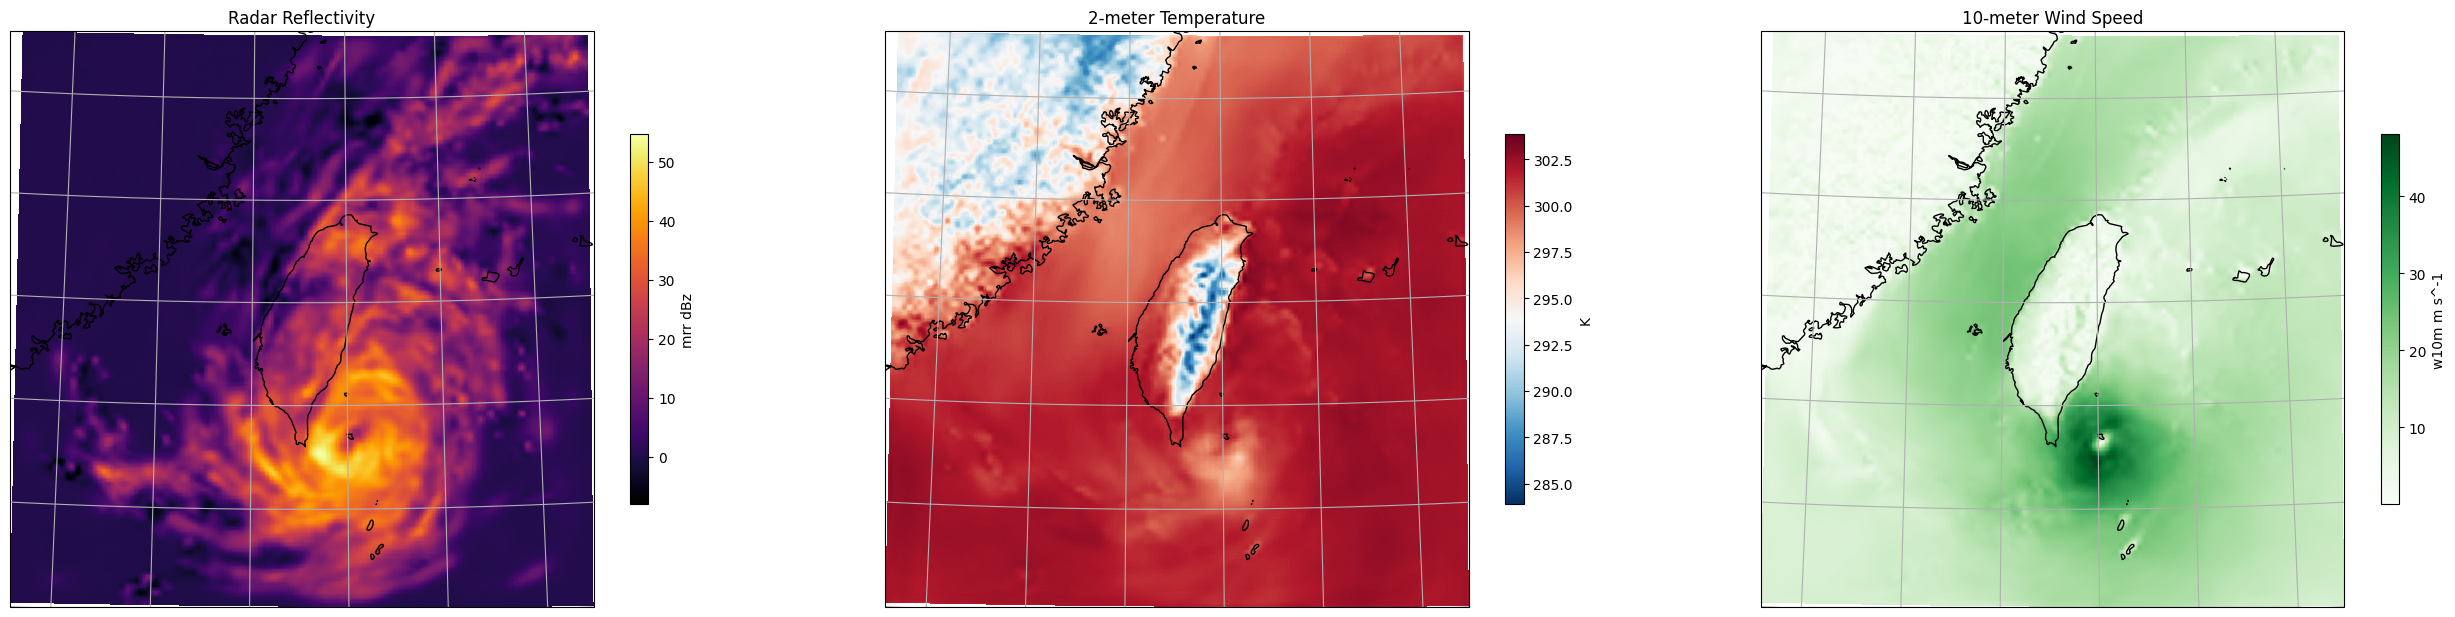

In [24]:
# SPDX-FileCopyrightText: Copyright (c) 2024-2025 NVIDIA CORPORATION & AFFILIATES.
# SPDX-FileCopyrightText: All rights reserved.
# SPDX-License-Identifier: Apache-2.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# %%
"""
Generative Downscaling
========================

Generative downscaling over Taiwan using CorrDiff diffusion model.

This example will demonstrate how to user Nvidia's CorrDiff model, trained for
predicting weather over Taiwan, to perform generative downscaling from quarter degree
global forecast data to ~3km.

This checkpoint was trained on ERA5 data and WRF data that spans 2018-2021 at one hour
time resolution. In this example, we demonstrate an application to GFS data for a typhoon
super-resolution from 2023. The model's performance on GFS data and on data from this year
has not been evaluated.

In this example you will learn:

- Creating a custom workflow for running CorrDiff inference
- Creating a data-source for CorrDiff's input
- Initializing and running CorrDiff diagnostic model
- Post-processing results.
"""

# %%
# Creating a Simple CorrDiff Workflow
# -----------------------------------
#
# As usual, we start with creating a simple workflow to run CorrDiff in. To maximize the
# generalization of this workflow, we use dependency injection following the pattern
# provided inside :py:obj:`earth2studio.run`. Since CorrDiff is a diagnostic model, this
# workflow won't predict a time-series, rather just an instantaneous prediction.
#
#
# For this workflow, we specify
#
# - time: Input list of datetimes / strings to run inference for
# - corrdiff: The initialized CorrDiffTaiwan model
# - data: Initialized data source to fetch initial conditions from
# - io: IOBackend
# - number_of_samples: Number of samples to generate from the model

# %%
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # TODO: make common example prep function

from collections import OrderedDict
from datetime import datetime

import numpy as np
import torch
from loguru import logger

from earth2studio.data import DataSource, prep_data_array
from earth2studio.io import IOBackend
from earth2studio.models.dx import CorrDiffTaiwan
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array


def run(
    time: list[str] | list[datetime] | list[np.datetime64],
    corrdiff: CorrDiffTaiwan,
    data: DataSource,
    io: IOBackend,
    number_of_samples: int = 1,
) -> IOBackend:
    """CorrDiff infernce workflow

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        List of string, datetimes or np.datetime64
    corrdiff : CorrDiffTaiwan
        CorrDiff mode
    data : DataSource
        Data source
    io : IOBackend
        IO object
    number_of_samples : int, optional
        Number of samples to generate, by default 1

    Returns
    -------
    IOBackend
        Output IO object
    """
    logger.info("Running corrdiff inference!")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    logger.info(f"Inference device: {device}")

    corrdiff = corrdiff.to(device)
    # Update the number of samples for corrdiff to generate
    corrdiff.number_of_samples = number_of_samples

    # Fetch data from data source and load onto device
    time = to_time_array(time)
    x, coords = prep_data_array(
        data(time, corrdiff.input_coords()["variable"]), device=device
    )
    x, coords = map_coords(x, coords, corrdiff.input_coords())

    logger.success(f"Fetched data from {data.__class__.__name__}")

    # Set up IO backend
    output_coords = corrdiff.output_coords(corrdiff.input_coords())
    total_coords = OrderedDict(
        {
            "time": coords["time"],
            "sample": output_coords["sample"],
            "lat": output_coords["lat"],
            "lon": output_coords["lon"],
        }
    )
    io.add_array(total_coords, output_coords["variable"])

    logger.info("Inference starting!")
    x, coords = corrdiff(x, coords)
    io.write(*split_coords(x, coords))

    logger.success("Inference complete")
    return io


# %%
# Set Up
# ------
# With the workflow defined, the next step is initializing the needed components from
# Earth-2 studio
#
# It's clear we need the following:
#
# - Diagnostic Model: CorrDiff model for Taiwan :py:class:`earth2studio.models.dx.CorrDiffTaiwan`.
# - Datasource: Pull data from the GFS data api :py:class:`earth2studio.data.GFS`.
# - IO Backend: Save the outputs into a Zarr store :py:class:`earth2studio.io.ZarrBackend`.
#

# %%
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend

# Create CorrDiff model
package = CorrDiffTaiwan.load_default_package()
corrdiff = CorrDiffTaiwan.load_model(package)

# Create the data source
data = GFS()

# Create the IO handler, store in memory
io = ZarrBackend()

# %%
# Execute the Workflow
# --------------------
# With all components initialized, running the workflow is a single line of Python code.
# Workflow will return the provided IO object back to the user, which can be used to
# then post process. Some have additional APIs that can be handy for post-processing or
# saving to file. Check the API docs for more information.
#
# For the inference we will predict 1 sample for a particular timestamp representing
# Typhoon Koinu.

# %%
io = run(["2023-10-04T18:00:00"], corrdiff, data, io, number_of_samples=1)

# %%
# Post Processing
# ---------------
# The last step is to post process our results. Cartopy is a great library for plotting
# fields on projections of a sphere.
#
# Notice that the Zarr IO function has additional APIs to interact with the stored data.

# %%
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

projection = ccrs.LambertConformal(
    central_longitude=io["lon"][:].mean(),
)

fig = plt.figure(figsize=(4 * 8, 8))

ax0 = fig.add_subplot(1, 3, 1, projection=projection)
c = ax0.pcolormesh(
    io["lon"],
    io["lat"],
    io["mrr"][0, 0],
    transform=ccrs.PlateCarree(),
    cmap="inferno",
)
plt.colorbar(c, ax=ax0, shrink=0.6, label="mrr dBz")
ax0.coastlines()
ax0.gridlines()
ax0.set_title("Radar Reflectivity")

ax1 = fig.add_subplot(1, 3, 2, projection=projection)
c = ax1.pcolormesh(
    io["lon"],
    io["lat"],
    io["t2m"][0, 0],
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
)
plt.colorbar(c, ax=ax1, shrink=0.6, label="K")
ax1.coastlines()
ax1.gridlines()
ax1.set_title("2-meter Temperature")

ax2 = fig.add_subplot(1, 3, 3, projection=projection)
c = ax2.pcolormesh(
    io["lon"],
    io["lat"],
    np.sqrt(io["u10m"][0, 0] ** 2 + io["v10m"][0, 0] ** 2),
    transform=ccrs.PlateCarree(),
    cmap="Greens",
)
plt.colorbar(c, ax=ax2, shrink=0.6, label="w10m m s^-1")
ax2.coastlines()
ax2.gridlines()
ax2.set_title("10-meter Wind Speed")

plt.savefig("outputs/04_corr_diff_prediction.jpg")
